In [2]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"])

0

In [3]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded correctly!")

All libraries loaded correctly!


### 1.1 Load Burned Areas
We load the annual burned area shapefiles for each year (2021–2024). Each file contains 
the perimeters of areas affected by fire that year.

In [7]:
import geopandas as gpd

burned_2021 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2021/ardida_2021.shp")
burned_2022 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2022/ardida_2022.shp")
burned_2023 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2023/ardida_2023.shp")
burned_2024 = gpd.read_file("../data/raw/Territórios_Ardidos/ardida_2024/ardida_2024.shp")

print("2021:", burned_2021.shape)
print("2022:", burned_2022.shape)
print("2023:", burned_2023.shape)
print("2024:", burned_2024.shape)

2021: (918, 23)
2022: (1786, 24)
2023: (1736, 24)
2024: (1558, 23)


### 1.2 Check Coordinate Reference Systems
Before merging the layers we verify that all datasets share the same coordinate 
reference system (CRS). Inconsistent CRS would cause spatial misalignment.

In [8]:
print("2021 CRS:", burned_2021.crs)
print("2022 CRS:", burned_2022.crs)
print("2023 CRS:", burned_2023.crs)
print("2024 CRS:", burned_2024.crs)

2021 CRS: EPSG:3763
2022 CRS: EPSG:3763
2023 CRS: EPSG:3763
2024 CRS: EPSG:3763


### 1.3 Merge Burned Areas into a Single Cumulative Layer
We combine the four annual layers into one dataset representing all areas 
burned at least once between 2021 and 2024. We add a year column first so 
we can still tell which fire belongs to which year after merging.

In [9]:
import pandas as pd

# Add a year column to each before merging
burned_2021["year"] = 2021
burned_2022["year"] = 2022
burned_2023["year"] = 2023
burned_2024["year"] = 2024

# Keep only the columns we need to avoid the column mismatch issue
cols = ["year", "geometry"]
burned_all = pd.concat([
    burned_2021[cols],
    burned_2022[cols],
    burned_2023[cols],
    burned_2024[cols]
])

# Reset index
burned_all = burned_all.reset_index(drop=True)

print("Total fire perimeters:", len(burned_all))
print(burned_all.head())

Total fire perimeters: 5998
   year                                           geometry
0  2021  POLYGON ((91853.576 232910.448, 91861.167 2329...
1  2021  POLYGON ((101406.3 168809.703, 101410.269 1688...
2  2021  POLYGON ((111535.884 170107.817, 111535.222 17...
3  2021  MULTIPOLYGON (((-55661.361 -253385.417, -55657...
4  2021  POLYGON ((-49809.417 -284169.64, -49765.761 -2...


### 1.4 Visualise Cumulative Burned Areas
A quick map to confirm the data loaded and merged correctly, with each 
year shown in a different colour.

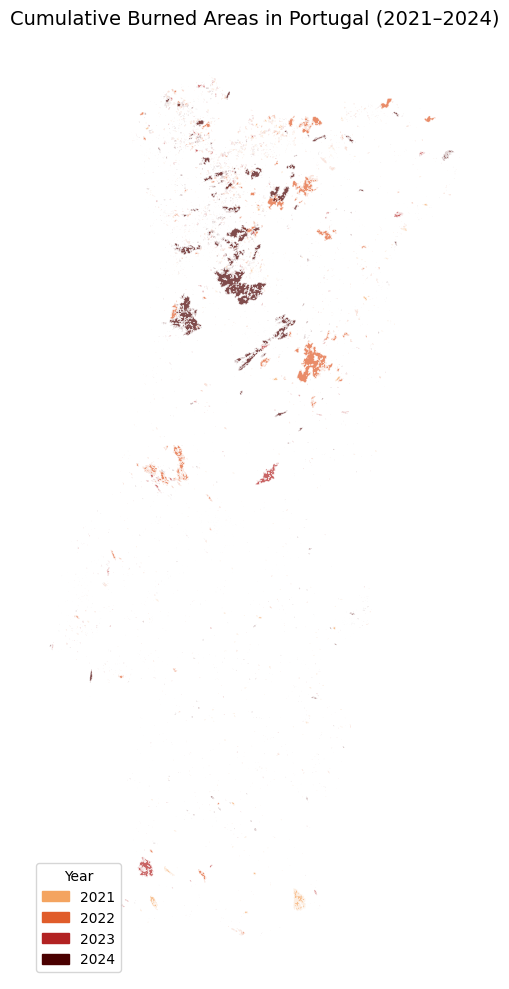

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 10))

colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

for year, color in colors.items():
    burned_all[burned_all["year"] == year].plot(
        ax=ax, color=color, linewidth=0.3, edgecolor="white", alpha=0.7
    )

# Legend
patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="lower left")

ax.set_title("Cumulative Burned Areas in Portugal (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150)
plt.show()

### 1.5 Load Portugal Boundaries
We load the Portugal boundary shapefile to use as a background for our maps.
We reproject it to EPSG:3763 to match the burned areas layer.

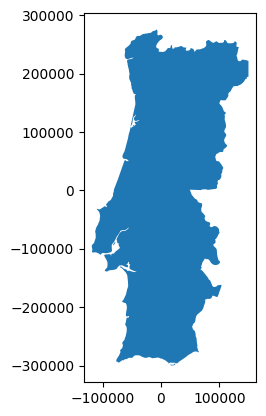

In [19]:
from shapely.geometry import box

world = gpd.read_file("../data/raw/portugal_boundaries/ne_10m_admin_0_countries_prt.shp").to_crs("EPSG:3763")

portugal = world[world["ADMIN"] == "Portugal"]

# Clip to mainland Portugal only (removes Azores and Madeira)
mainland_bbox = box(-150000, -350000, 150000, 350000)
portugal_mainland = portugal.clip(mainland_bbox)

portugal_mainland.plot()
plt.show()

### 1.6 Visualise Cumulative Burned Areas with Portugal Boundary
We replot the burned areas map now with the Portugal mainland boundary 
as background, with each year shown in a different colour.

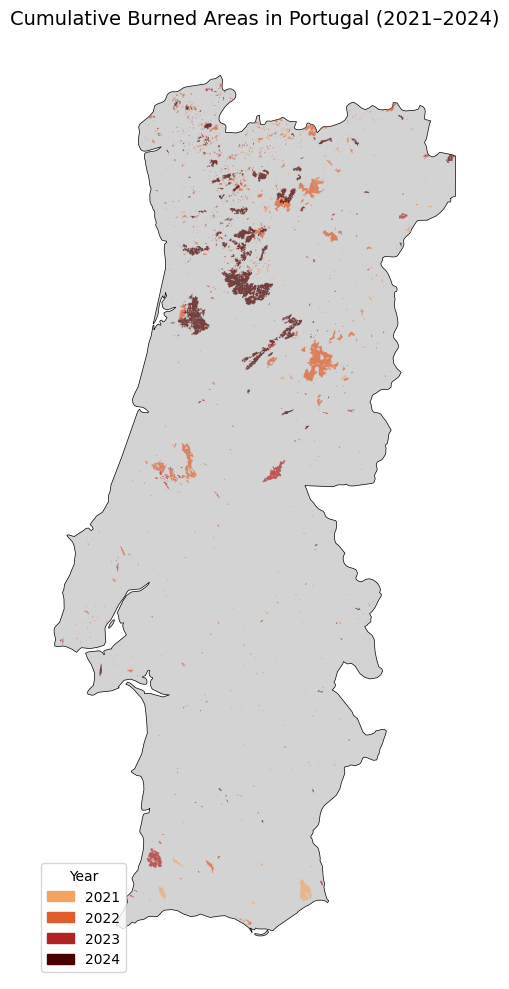

In [23]:
fig, ax = plt.subplots(figsize=(8, 10))

# Plot Portugal boundary as background
portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)


# Plot burned areas by year
colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}
for year, color in colors.items():
    burned_all[burned_all["year"] == year].plot(
        ax=ax, color=color, linewidth=0.3, edgecolor="none", alpha=0.7
    )

# Legend
patches = [mpatches.Patch(color=c, label=str(y)) for y, c in colors.items()]
ax.legend(handles=patches, title="Year", loc="lower left")

ax.set_title("Cumulative Burned Areas in Portugal (2021–2024)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/burned_areas_2021_2024.png", dpi=150)
plt.show()

### 1.7 Spatio-Temporal Analysis
We analyse how burned areas evolved across the four years of the study period,
looking at both the total area burned per year and the spatial distribution of fires.

   year  total_area_ha
0  2021   27064.547181
1  2022  107819.826998
2  2023   34022.289615
3  2024  138191.864251


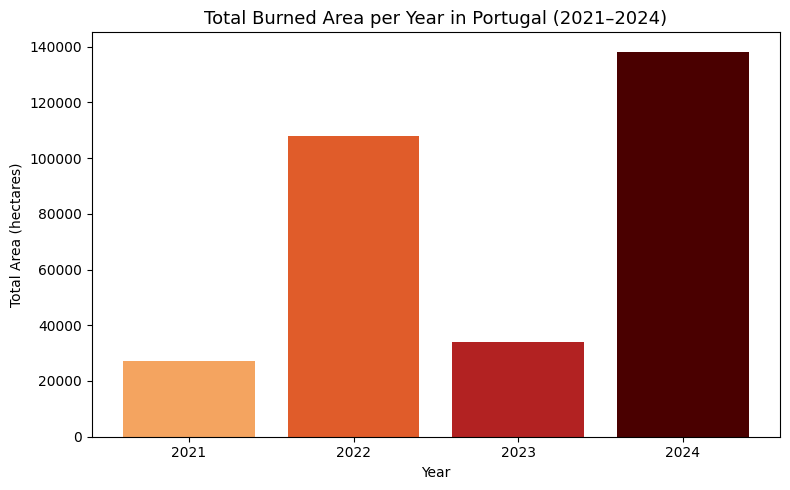

In [24]:
# Calculate total burned area per year
area_per_year = burned_all.copy()
area_per_year["area_ha"] = area_per_year.geometry.area / 10000  # convert m2 to hectares

summary = area_per_year.groupby("year")["area_ha"].sum().reset_index()
summary.columns = ["year", "total_area_ha"]

print(summary)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary["year"], summary["total_area_ha"], 
       color=["#f4a460", "#e05c2a", "#b22222", "#4a0000"])
ax.set_title("Total Burned Area per Year in Portugal (2021–2024)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Area (hectares)")
ax.set_xticks([2021, 2022, 2023, 2024])
plt.tight_layout()
plt.savefig("../outputs/burned_area_per_year.png", dpi=150)
plt.show()

### 1.8 Spatial Distribution by Year
We plot each year separately to visualise how the spatial pattern of 
fires shifted across the study period.

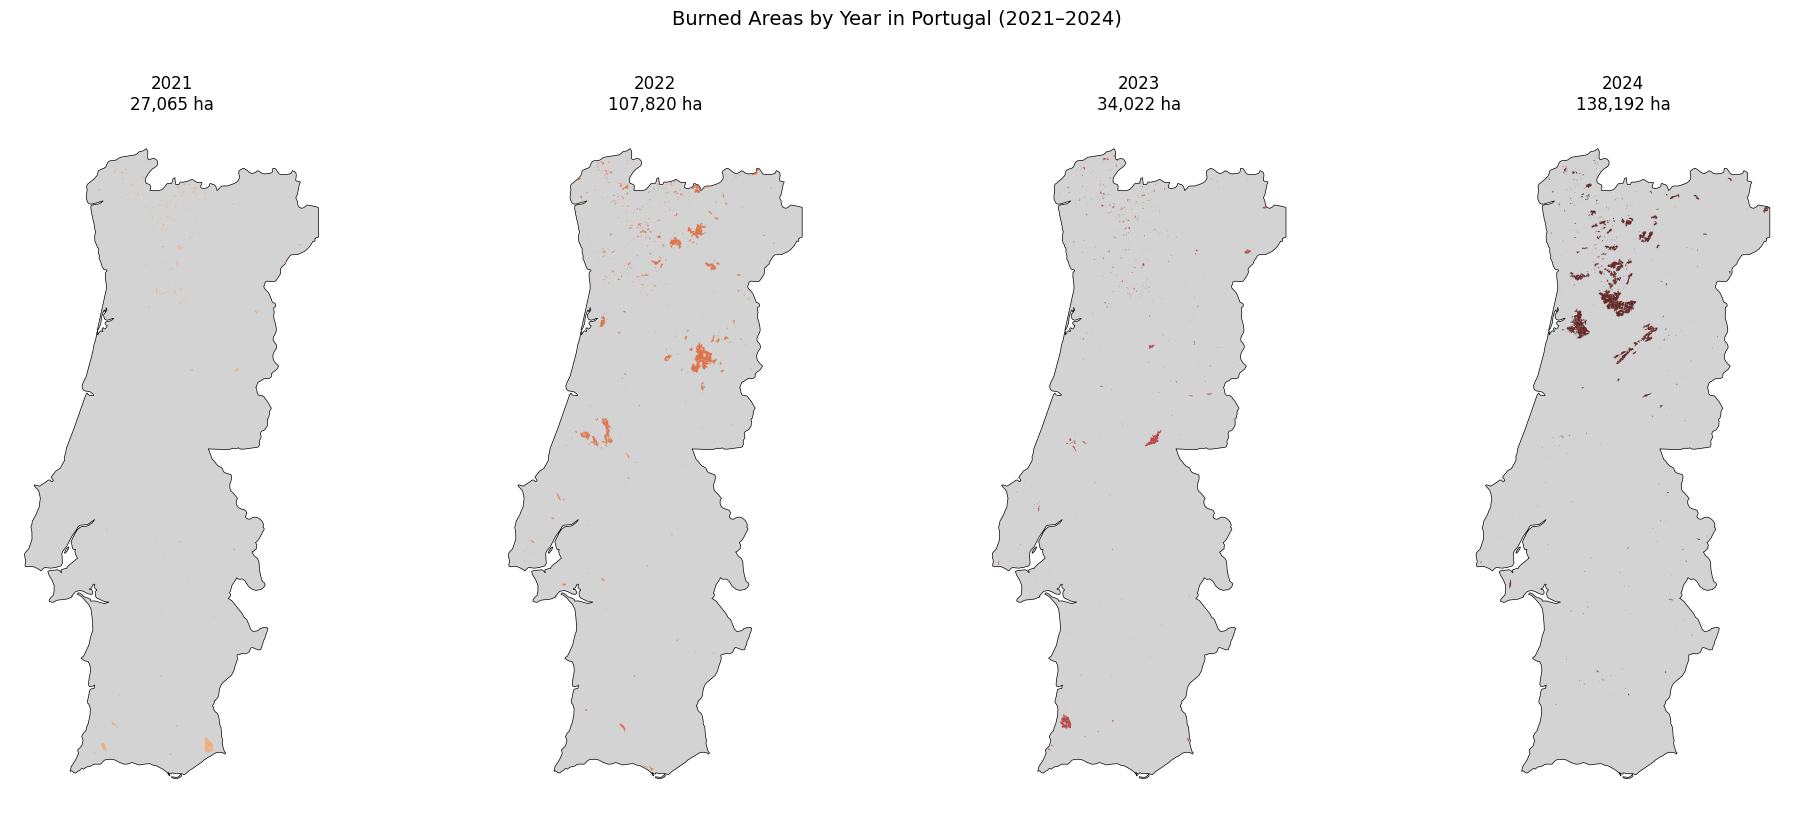

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 8))

colors = {2021: "#f4a460", 2022: "#e05c2a", 2023: "#b22222", 2024: "#4a0000"}

for ax, (year, color) in zip(axes, colors.items()):
    portugal_mainland.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    burned_all[burned_all["year"] == year].plot(
        ax=ax, color=color, edgecolor="none", alpha=0.8
    )
    ax.set_title(f"{year}\n{summary[summary['year']==year]['total_area_ha'].values[0]:,.0f} ha", 
                 fontsize=12)
    ax.set_axis_off()

plt.suptitle("Burned Areas by Year in Portugal (2021–2024)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/burned_areas_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Loading Additional Risk Factors
### 2.1 Load Conjunctural Hazard Rasters
We load the four annual climate-driven fire hazard rasters (2021–2024) 
and average them into a single multi-year trend layer.

In [33]:

hazard_paths = {
    2021: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2021/perigosidade_conjuntural_2021.tif",
    2022: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2022/perigosidade_conjuntural_2022.tif",
    2023: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2023/perigosidade_conjuntural2023.tif",
    2024: "../data/raw/conjunctural_hazard_maps/conjunctural_hazard_2024/PerigosidadeConjuntural_2024/perigosidade_conjuntural2024.tif",
}

for year, path in hazard_paths.items():
    with rasterio.open(path) as src:
        print(f"{year}: shape={src.shape}, CRS={src.crs}, dtype={src.dtypes[0]}")


2021: shape=(23060, 11253), CRS=EPSG:3763, dtype=uint8
2022: shape=(23197, 12126), CRS=EPSG:3763, dtype=uint8
2023: shape=(23061, 11254), CRS=EPSG:3763, dtype=uint8
2024: shape=(23060, 11253), CRS=EPSG:3763, dtype=uint8
